# Take a Peek — 2-class Demo with DCAMA

This notebook is split in two independent parts.

**Part 1 — Quick demo** loads a pre-saved episode from `assets/episode/episode.pt`
(committed to the repository) and runs TaP without any dataset setup.

**Part 2 — Full dataset** shows how to sample new episodes from COCO 20ⁱ,
run TaP on them, and save any episode for later re-use.

---
## Part 1 · Quick Demo
*Only the model checkpoints are required — no COCO download needed.*

### 1. Imports and visualisation helpers

In [77]:
import os, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from peft import LoraConfig

# ensure we run from the repo root
if os.path.basename(os.getcwd()) != 'TakeAPeek':
    os.chdir('..')

from tap import TakeAPeek
from tap.validate import get_dcama

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

# ── visualisation helpers ─────────────────────────────────────────────────────
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

PALETTE = np.array([[0.5, 0.5, 0.5],   # background — grey
                    [0.9, 0.2, 0.2],   # class A    — red
                    [0.2, 0.4, 0.9]])  # class B    — blue

LEGEND = [mpatches.Patch(color=PALETTE[i], label=l)
          for i, l in enumerate(['Background', 'Class A', 'Class B'])]

def denorm(t):
    return (t.cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)

def mask_to_rgb(mask_hw):
    arr = mask_hw.cpu().numpy().astype(int)
    return PALETTE[np.clip(arr, 0, len(PALETTE) - 1)]

def resize_mask(mask_hw, H, W):
    return torch.nn.functional.interpolate(
        mask_hw.float().unsqueeze(0).unsqueeze(0),
        size=(H, W), mode='nearest',
    ).long().squeeze()

def overlay(img_chw, mask_hw, orig_hw=None, alpha=0.45):
    """Blend a colour mask onto a normalised image tensor.

    Args:
        orig_hw: (h, w) of the valid (non-padded) region of mask_hw.
    """
    img = denorm(img_chw).permute(1, 2, 0).numpy()
    H, W = img.shape[:2]
    if orig_hw is not None:
        oh, ow = orig_hw
        mask_hw = mask_hw[:oh, :ow]
    if tuple(mask_hw.shape) != (H, W):
        mask_hw = resize_mask(mask_hw, H, W)
    return img * (1 - alpha) + mask_to_rgb(mask_hw) * alpha

Device: cuda


### 2. Load DCAMA

In [78]:
# Swin-B backbone, trained on COCO fold 0
model, image_size = get_dcama(dataset='coco', val_fold_idx=0)
model = model.to(DEVICE)   # keep train mode — TakeAPeek handles eval/train internally
print(f'Image size : {image_size}')
print(f'Backbone   : {model.backbone}')

Image size : 384
Backbone   : swin


### 3. Configure TakeAPeek

In [79]:
lora_cfg = LoraConfig(
    r=64,
    lora_alpha=64.0,
    target_modules=['qkv'],   # Swin-B attention projections
    lora_dropout=0.1,
    bias='none',
)

tap = TakeAPeek(
    model=model,
    lora_config=lora_cfg,
    num_iterations=8,
    lr=1e-3,
    device=DEVICE,
)

### 4. Load the saved episode

In [80]:
EPISODE_DIR = 'assets/episode'

ckpt  = torch.load(os.path.join(EPISODE_DIR, 'episode.pt'),
                   map_location=DEVICE, weights_only=False)
batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
         for k, v in ckpt['batch'].items()}
gt    = ckpt['gt'].to(DEVICE)

B, M, C, H, W = batch['images'].shape
# Derive N_WAYS and K_SHOTS from the tensor shape so old episodes
# without saved metadata are handled correctly.
N_WAYS  = ckpt.get('n_ways', 2)
K_SHOTS = (M - 1) // N_WAYS        # M = 1 (query) + N_WAYS * K_SHOTS

print(f'images : {tuple(batch["images"].shape)}   (B, 1+N*K, C, H, W)')
print(f'gt     : {tuple(gt.shape)}')
print(f'N_WAYS={N_WAYS}, K_SHOTS={K_SHOTS}')


images : (1, 7, 3, 384, 384)   (B, 1+N*K, C, H, W)
gt     : (1, 7, 500, 500)
N_WAYS=2, K_SHOTS=3


### 5. Visualise the episode

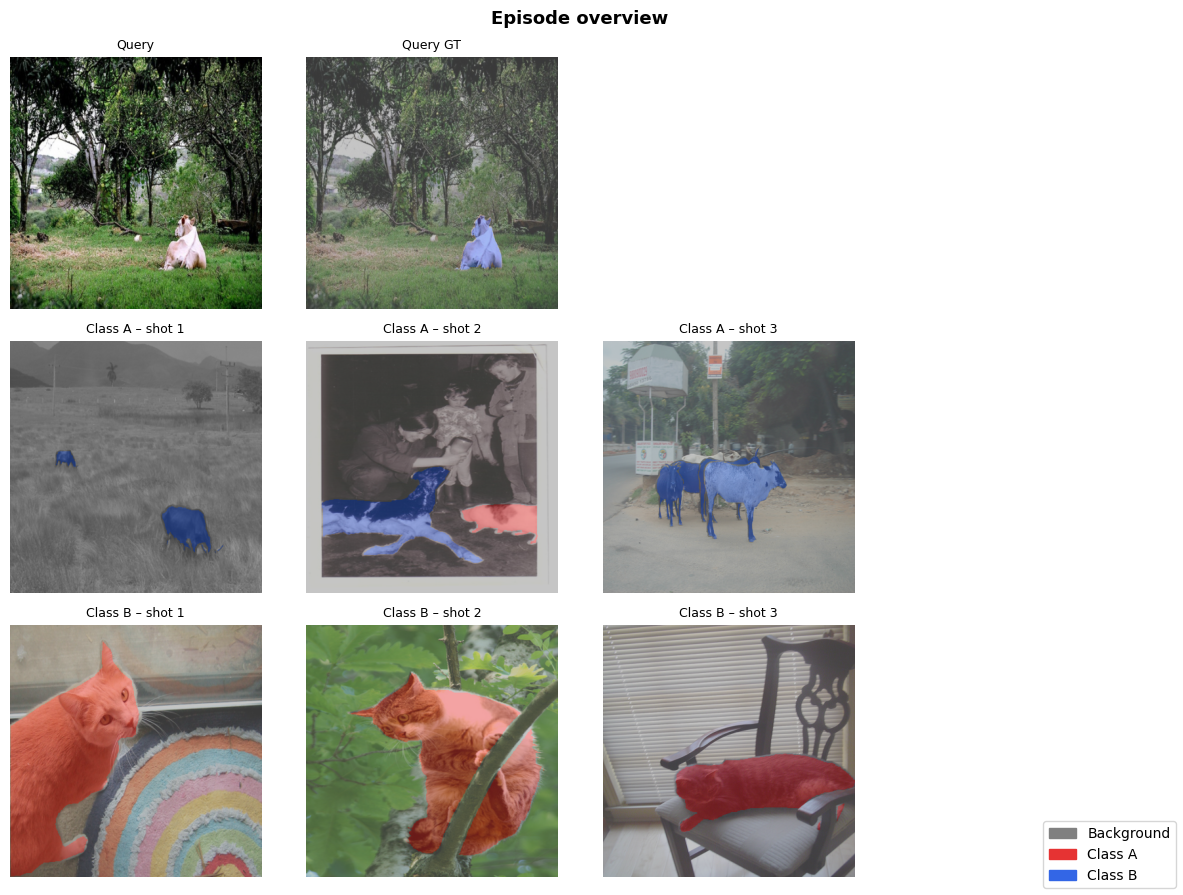

In [81]:
images = batch['images'][0]    # (M, C, H, W)
gts    = gt[0]                 # (M, H, W)
dims   = batch['dims'][0]      # (M, 2)

query_img  = images[0];  query_gt  = gts[0];  query_dims  = dims[0].tolist()
support_imgs = images[1:]; support_gts = gts[1:]; support_dims = dims[1:]

class_a_imgs = support_imgs[:K_SHOTS]; class_b_imgs = support_imgs[K_SHOTS:]
class_a_gts  = support_gts[:K_SHOTS];  class_b_gts  = support_gts[K_SHOTS:]
class_a_dims = support_dims[:K_SHOTS]; class_b_dims = support_dims[K_SHOTS:]

fig, axes = plt.subplots(3, K_SHOTS + 1, figsize=(3 * (K_SHOTS + 1), 9))
fig.suptitle('Episode overview', fontsize=13, fontweight='bold')

axes[0, 0].imshow(denorm(query_img).permute(1, 2, 0))
axes[0, 0].set_title('Query', fontsize=9); axes[0, 0].axis('off')
axes[0, 1].imshow(overlay(query_img, query_gt, orig_hw=query_dims))
axes[0, 1].set_title('Query GT', fontsize=9); axes[0, 1].axis('off')
for j in range(2, K_SHOTS + 1): axes[0, j].axis('off')

for k in range(K_SHOTS):
    axes[1, k].imshow(overlay(class_a_imgs[k], class_a_gts[k],
                               orig_hw=class_a_dims[k].tolist()))
    axes[1, k].set_title(f'Class A – shot {k+1}', fontsize=9); axes[1, k].axis('off')
axes[1, K_SHOTS].axis('off')

for k in range(K_SHOTS):
    axes[2, k].imshow(overlay(class_b_imgs[k], class_b_gts[k],
                               orig_hw=class_b_dims[k].tolist()))
    axes[2, k].set_title(f'Class B – shot {k+1}', fontsize=9); axes[2, k].axis('off')
axes[2, K_SHOTS].axis('off')

fig.legend(handles=LEGEND, loc='lower right', fontsize=10)
plt.tight_layout(); plt.show()

### 6. Vanilla inference (no TaP)

In [82]:
from tap.substitutor import Substitutor

sub = Substitutor()
sub.reset((batch, gt))
query_batch, _ = next(iter(sub))
query_batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
               for k, v in query_batch.items()}

with torch.no_grad():
    vanilla_pred = model(query_batch)['logits'].argmax(dim=1)   # (B, H, W)

print('Unique predicted classes:', vanilla_pred.unique().tolist())

Unique predicted classes: [0, 1, 2]


### 7. TaP adaptation and inference

In [83]:
tap_pred = tap(batch, gt).argmax(dim=1)   # (B, H, W)

print('Unique predicted classes:', tap_pred.unique().tolist())

Unique predicted classes: [0, 1, 2]


### 8. Compare results

Vanilla mIoU : 0.5975
TaP     mIoU : 0.6416   (+0.0440)


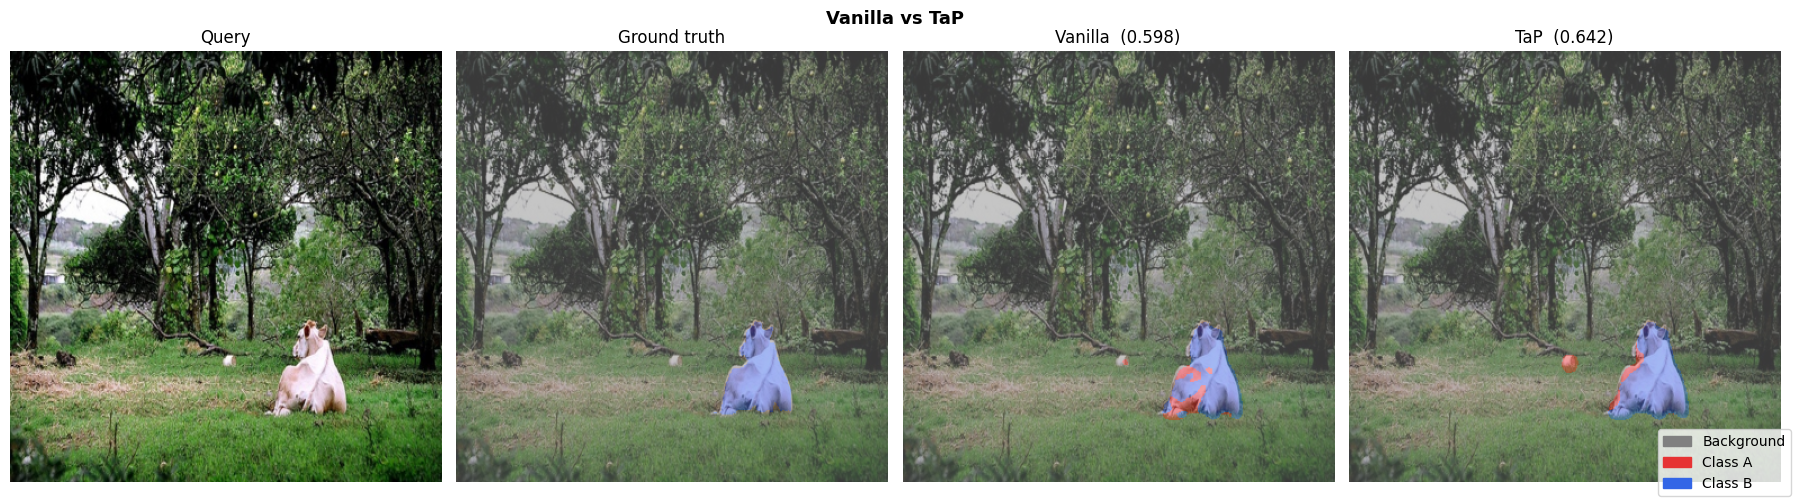

In [84]:
from torchmetrics import JaccardIndex

def miou(pred, target, num_classes=3):
    metric = JaccardIndex(task='multiclass', num_classes=num_classes,
                          average='macro', ignore_index=-100)
    return metric(pred.cpu(), target.cpu()).item()

q_h, q_w = batch['dims'][0, 0].tolist()
miou_vanilla = miou(vanilla_pred, query_gt.unsqueeze(0))
miou_tap     = miou(tap_pred,     query_gt.unsqueeze(0))

print(f'Vanilla mIoU : {miou_vanilla:.4f}')
print(f'TaP     mIoU : {miou_tap:.4f}   ({miou_tap - miou_vanilla:+.4f})')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Vanilla vs TaP', fontsize=13, fontweight='bold')
axes[0].imshow(denorm(query_img).permute(1, 2, 0));                       axes[0].set_title('Query')
axes[1].imshow(overlay(query_img, query_gt,          orig_hw=(q_h, q_w))); axes[1].set_title('Ground truth')
axes[2].imshow(overlay(query_img, vanilla_pred[0],   orig_hw=(q_h, q_w))); axes[2].set_title(f'Vanilla  ({miou_vanilla:.3f})')
axes[3].imshow(overlay(query_img, tap_pred[0],       orig_hw=(q_h, q_w))); axes[3].set_title(f'TaP  ({miou_tap:.3f})')
fig.legend(handles=LEGEND, loc='lower right', fontsize=10)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

---
## Part 2 · Try Your Own Episodes

Requires the COCO dataset and Pascal VOC to be set up (see README).
Run these cells to sample new episodes, experiment with TaP, and save any
episode back to `assets/episode/` for future use in Part 1.

### 9. Build the dataloader

In [ ]:
from copy import deepcopy
from tap.validate import dataset_args, dataloader_args, COCO_PARAMS, COCO_NAME
from tap.data import get_dataloaders

N_WAYS  = 2
K_SHOTS = 5
FOLD    = 0

da = deepcopy(dataset_args)
dl = deepcopy(dataloader_args)

da['datasets'][COCO_NAME] = {
    **COCO_PARAMS,
    'n_ways': N_WAYS,
    'n_shots': K_SHOTS,
    'val_num_samples': 20,
    'val_fold_idx': FOLD,
}
da['common']['image_size'] = image_size
dl['val_possible_batch_example_nums'] = [[1, 1]]

dataloader = get_dataloaders(da, dl, num_processes=1)[COCO_NAME]
iterator   = iter(dataloader)
print(f'Episodes available: {len(dataloader)}')

### 10. Sample an episode and run TaP

Re-run this cell to advance to the next episode.

In [ ]:
(batch, gt), _ = next(iterator)

batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
gt    = gt.to(DEVICE)

# Unpack for visualisation
images = batch['images'][0]; gts = gt[0]; dims = batch['dims'][0]
query_img  = images[0]; query_gt  = gts[0]; query_dims = dims[0].tolist()
support_imgs = images[1:]; support_gts = gts[1:]; support_dims = dims[1:]
class_a_imgs = support_imgs[:K_SHOTS]; class_b_imgs = support_imgs[K_SHOTS:]
class_a_gts  = support_gts[:K_SHOTS];  class_b_gts  = support_gts[K_SHOTS:]
class_a_dims = support_dims[:K_SHOTS]; class_b_dims = support_dims[K_SHOTS:]

# Vanilla
sub = Substitutor()
sub.reset((batch, gt))
qb, _ = next(iter(sub))
qb = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in qb.items()}
with torch.no_grad():
    vanilla_pred = model(qb)['logits'].argmax(dim=1)

# TaP
tap_pred = tap(batch, gt).argmax(dim=1)

q_h, q_w = dims[0].tolist()
mv = miou(vanilla_pred, query_gt.unsqueeze(0))
mt = miou(tap_pred,     query_gt.unsqueeze(0))
print(f'Vanilla {mv:.4f}  |  TaP {mt:.4f}  |  gain {mt - mv:+.4f}')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Vanilla ({mv:.3f}) vs TaP ({mt:.3f})', fontsize=12)
axes[0].imshow(denorm(query_img).permute(1, 2, 0));                      axes[0].set_title('Query')
axes[1].imshow(overlay(query_img, query_gt,        orig_hw=(q_h, q_w))); axes[1].set_title('Ground truth')
axes[2].imshow(overlay(query_img, vanilla_pred[0], orig_hw=(q_h, q_w))); axes[2].set_title(f'Vanilla  {mv:.3f}')
axes[3].imshow(overlay(query_img, tap_pred[0],     orig_hw=(q_h, q_w))); axes[3].set_title(f'TaP  {mt:.3f}')
fig.legend(handles=LEGEND, loc='lower right', fontsize=10)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

### 11. Save this episode

Overwrites `assets/episode/episode.pt` and regenerates the PNG assets.

In [ ]:
from PIL import Image

os.makedirs(EPISODE_DIR, exist_ok=True)

# ── tensors ────────────────────────────────────────────────────────────────────
torch.save(
    {
        'batch':   {k: v.cpu() if isinstance(v, torch.Tensor) else v for k, v in batch.items()},
        'gt':      gt.cpu(),
        'n_ways':  N_WAYS,
        'k_shots': K_SHOTS,
    },
    os.path.join(EPISODE_DIR, 'episode.pt'),
)
print('Saved episode.pt')

# ── PNG overlays ───────────────────────────────────────────────────────────────
def save_png(arr, name):
    Image.fromarray((arr * 255).clip(0, 255).astype('uint8')).save(
        os.path.join(EPISODE_DIR, name))

save_png(denorm(query_img).permute(1, 2, 0).numpy(), 'query.png')
save_png(overlay(query_img, query_gt,        orig_hw=(q_h, q_w)), 'query_gt.png')
save_png(overlay(query_img, vanilla_pred[0], orig_hw=(q_h, q_w)), 'query_vanilla.png')
save_png(overlay(query_img, tap_pred[0],     orig_hw=(q_h, q_w)), 'query_tap.png')

for k in range(K_SHOTS):
    save_png(overlay(class_a_imgs[k], class_a_gts[k],
                     orig_hw=class_a_dims[k].tolist()), f'support_a_{k+1}.png')
    save_png(overlay(class_b_imgs[k], class_b_gts[k],
                     orig_hw=class_b_dims[k].tolist()), f'support_b_{k+1}.png')

print(f'PNGs saved to {EPISODE_DIR}/:')
for f in sorted(os.listdir(EPISODE_DIR)):
    print(f'  {f}')